## View human learning curve statistics for Experiment 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from hobj.benchmarks import MutatorHighVarBenchmark
benchmark1 = MutatorHighVarBenchmark()
target_statistics = benchmark1.target_statistics
print(target_statistics)

<xarray.LearningCurveStatistics> Size: 103MB
Dimensions:           (subtask: 64, trial: 100, boot_iter: 1000)
Coordinates:
  * subtask           (subtask) <U35 9kB 'MutatorB2000_0,MutatorB2000_4718' ....
Dimensions without coordinates: trial, boot_iter
Data variables:
    phat              (subtask, trial) float64 51kB 0.44 0.68 0.62 ... 0.68 0.86
    varhat_phat       (subtask, trial) float64 51kB 0.005029 ... 0.002457
    boot_phat         (boot_iter, subtask, trial) float64 51MB 0.44 ... 0.84
    boot_varhat_phat  (boot_iter, subtask, trial) float64 51MB 0.005029 ... 0...


### Plot target statistics

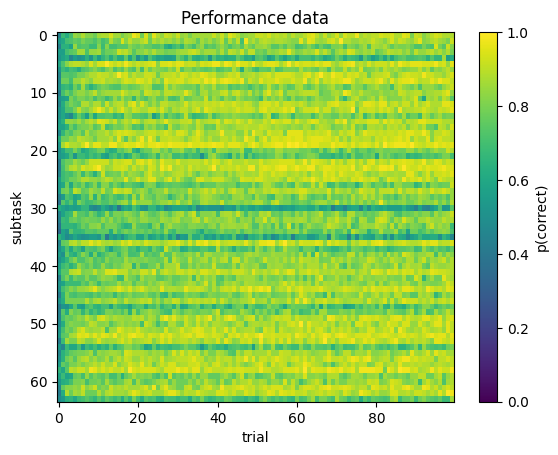

In [3]:
plt.figure()
plt.imshow(target_statistics.phat, aspect='auto', cmap = 'viridis', vmin = 0, vmax = 1)
plt.xlabel('trial')
plt.ylabel('subtask')
plt.title("Performance data")
plt.colorbar(label='p(correct)')
plt.show()


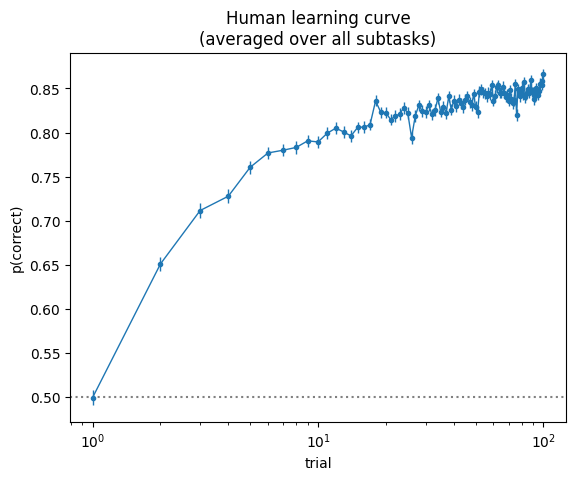

In [4]:
# Calculate the subtask-averaged learning curve
glc = target_statistics.phat.mean('subtask')

# Compute standard error using the bootstrap samples:
glc_se = target_statistics.boot_phat.mean('subtask').std('boot_iter', ddof = 1) 

plt.figure()
plt.errorbar(np.arange(len(glc))+1, glc, yerr = glc_se,  lw = 1, elinewidth = 1, marker = '.')
plt.axhline(0.5, ls = ':', color = 'gray')
plt.xscale('log')
plt.xlabel('trial')
plt.ylabel('p(correct)')
plt.title("Human learning curve\n(averaged over all subtasks)")
plt.show()

## View behavioral and image data for a specific subtask

In [5]:
# Response data for each subject
target_data = benchmark1.target_data # subtask_name: worker_id: [bool]

# View example data for the first subtask
example_subtask = list(target_data.keys())[0]
example_worker_id = list(target_data[example_subtask].keys())[0]
print(f'Showing behavioral data for subtask {example_subtask}, Worker {example_worker_id}:\n')
print(target_data[example_subtask][example_worker_id])

Showing behavioral data for subtask MutatorB2000_0,MutatorB2000_4718, Worker 95396ff08c73aef1e33db1893f8b53d13bef93b0047fd222cd5a79e3df65cb1c:

[True, False, True, False, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, False, True, False, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, False, False, True, True, True, True, True, True, False, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True]


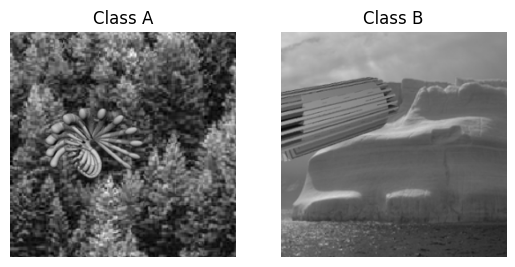

In [6]:
# Get the image distribution for this subtask 
simulator = benchmark1.subtask_name_to_subtask[example_subtask]
classA_images = simulator.classA
classB_images = simulator.classB

# Show some example images for this subtask:
example_imageA = classA_images[0].get_image_data()
example_imageB = classB_images[0].get_image_data()

fig, ax = plt.subplots(1, 2)
ax[0].imshow(example_imageA)
ax[0].axis('off')
ax[0].set_title('Class A')
ax[1].imshow(example_imageB)
ax[1].axis('off')
ax[1].set_title('Class B')
plt.show()


